# Планировщик: VLM-таблица вместо VLM в контуре

In [1]:
!pip install -q -U minigrid
!pip install -q -U "transformers>=4.49" accelerate qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 97.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 105.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 59.5 MB/s eta 0:00:00:00:0100:01


### 1. Импорты, пути, модель

In [3]:
import os, sys, gc, json, time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

# --- датасет с исходниками: подхватываем корень и src/, что найдётся ---
CANDIDATE_DIRS = [
    "/kaggle/input/datasets/kirillwerd/world-model-new",
    "/kaggle/input/datasets/kirillwerd/world-model-new/src",
]
for d in CANDIDATE_DIRS:
    if os.path.isdir(d) and d not in sys.path:
        sys.path.append(d)

from RSSM import RSSM
from data import ACTION_DIM
from env_tasks import MultiObjEnv
from fast_planner import (MOVE_ACTIONS, prep_frame, run_episode_v2,
                          reward_objective, probe_imagination)
from state_table import (enumerate_agent_states, build_state_values,
                         StateTable, table_objective, value_heatmap,
                         inspect_states)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0); np.random.seed(0)
print("torch", torch.__version__, "|", DEVICE,
      torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

MODEL_PATH = "/kaggle/input/models/kirillwerd/world-model/pytorch/default/3/world-model.pt"
model = RSSM(action_dim=ACTION_DIM).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("веса загружены:", MODEL_PATH)

torch 2.10.0+cu128 | cuda Tesla T4
веса загружены: /kaggle/input/models/kirillwerd/world-model/pytorch/default/3/world-model.pt


### 2. Конфиг
`GRID_SIZE` обязан совпадать со средой, на которой обучался чекпойнт — иначе декодер и эталоны живут в разных мирах.

In [5]:
GRID_SIZE = 10          # = среда трейна чекпойнта
TASKS     = ('key', 'door', "goal")

VLM_PROMPTS = {
    "key":  "the red agent is right next to the yellow key, pointing at it",
    "door": "the red agent is right next to the blue door, pointing at it",
    "goal": "the red agent completely overlaps the green square",
}

SEEDS        = tuple(range(10))
MAX_STEPS    = 64      # бюджет шагов, одинаковый для всех методов
HORIZON      = 10      # воображение теперь дёшево (VLM нет) — берём с запасом
N_CAND       = 300     # кандидатов у ОБОИХ планировщиков
REPLAN_EVERY = 1

TABLES_PATH_READ   = "/kaggle/input/datasets/kirillwerd/state-table/QWEN_7B.pt"
TABLES_PATH_WRITE   = "/kaggle/working/state_taples.pt"
FORCE_REBUILD = False  # True — пересчитать таблицы Qwen'ом заново

SMOKE = False          # True — быстрая проверка пайплайна на 2 сидах
if SMOKE:
    SEEDS = (0, 1)

env = MultiObjEnv(size=GRID_SIZE, render_mode="rgb_array", highlight=False)
env.reset(seed=0)
print(f"env {GRID_SIZE}x{GRID_SIZE} | key {env.key_pos} "
      f"door {env.door_pos} goal {env.goal_pos}")

env 10x10 | key (1, 5) door (8, 1) goal (8, 8)


### 3. Санити: чекпойнт и среда из одного мира?
Постериор видит текущий кадр, так что реконструкция обязана быть чёткой. Мутная картинка = чекпойнт от другой версии среды.

### 4. Этап 1 — таблица VLM-оценок (Qwen один раз)
~212 состояний × 3 промпта ≈ 640 форвардов, ~3–5 мин на T4. Кросс-нормировка по строке (`p_task / Σp`) — дебиасинг из кросс-матричных тестов. Таблица сохраняется на диск; повторные запуски Qwen не грузят вовсе.

In [7]:
if os.path.exists(TABLES_PATH_READ) and not FORCE_REBUILD:
    blob = torch.load(TABLES_PATH_READ, weights_only=False)
    frames_ref, states, tables = blob["frames"], blob["states"], blob["tables"]
    print(f"таблицы загружены с диска: {len(states)} состояний")
else:
    from Kaggle_Scorer import KaggleScorer
    scorer = KaggleScorer(model="Qwen/Qwen2.5-VL-7B-Instruct", 
                          upscale=448, 
                          max_pixels = 512*512,
                          device_map='auto',
                          max_memory={0: "13GiB", 1: "13GiB"})  # 2B хеджирует, 7B не влезает в T4
    t0 = time.time()
    frames_ref, states = enumerate_agent_states(env)
    tables = build_state_values(scorer, frames_ref, VLM_PROMPTS)
    torch.save({"frames": frames_ref, "states": states, "tables": tables},
               TABLES_PATH_WRITE)
    print(f"таблицы построены за {time.time() - t0:.0f}s -> {TABLES_PATH_WRITE}")
    del scorer; gc.collect(); torch.cuda.empty_cache()          # Qwen дальше не нужен

таблицы загружены с диска: 212 состояний


### 5. Ландшафт VLM — фигура в отчёт
Красная рамка — целевой объект задачи. Здесь же офлайн видно старые фейлы: occlusion (агент НА goal) и путаницу key/goal — если промпт goal светится у ключа, это видно до всякого планирования.

таблицы загружены с диска: 212 состояний


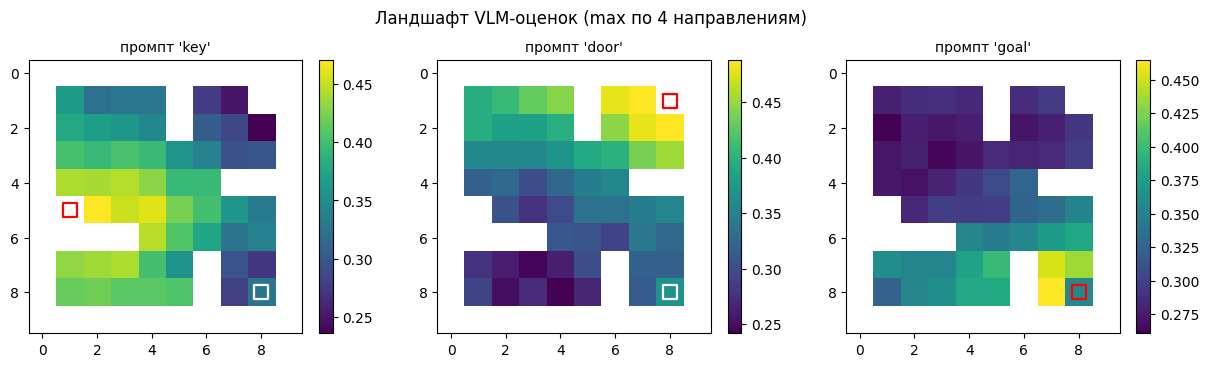

occlusion-проверка — агент СТОИТ НА goal, 4 направления:
[((8, 8, 0), 0.3555), ((8, 8, 1), 0.3266), ((8, 8, 2), 0.3261), ((8, 8, 3), 0.3266)]


In [20]:
blob = torch.load("/kaggle/input/datasets/kirillwerd/oldddd/top_table.pt", weights_only=False)
frames_ref, states, tables = blob["frames"], blob["states"], blob["tables"]
print(f"таблицы загружены с диска: {len(states)} состояний")

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
marks = {"key": tuple(env.key_pos), "door": tuple(env.door_pos),
         "goal": tuple(env.goal_pos)}
for ax, task in zip(axes, TASKS):
    hm = value_heatmap(states, tables[task], GRID_SIZE)
    im = ax.imshow(hm, origin="upper", cmap="viridis")
    for name, (px, py) in marks.items():
        ax.scatter([px], [py], marker="s", s=100, facecolors="none",
                   edgecolors="red" if name == task else "white", linewidths=1.6)
    ax.set_title(f"промпт '{task}'", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Ландшафт VLM-оценок (max по 4 направлениям)")
plt.tight_layout()
plt.savefig("/kaggle/working/vlm_landscape.png", dpi=150)
plt.show()

print("occlusion-проверка — агент СТОИТ НА goal, 4 направления:")
print(inspect_states(states, tables["goal"], [tuple(env.goal_pos)]))

### 6. Этап 2 — сравнение random / reward / VLM
Ожидание (главный результат для отчёта): reward-планировщик решает только `goal` — единственную задачу со спарсовой наградой среды; VLM-таблица таргетирует все три, меняя **только текст промпта**.

In [9]:
table_scorers = {t: StateTable(frames_ref, tables[t], DEVICE) for t in TASKS}
objectives = {
    "reward": {t: reward_objective(model) for t in TASKS},
    "vlm":    {t: table_objective(model, table_scorers[t], mode="sum")
               for t in TASKS},
}

def run_random_episode(env, task, seed, max_steps):
    env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    n = 0
    while n < max_steps and not env.task_success(task):
        env.step(int(rng.choice(MOVE_ACTIONS))); n += 1
    return bool(env.task_success(task)), n

In [12]:
methods = ("random", "reward", "vlm")
TASKS = ("goal",)
SEEDS        = tuple(range(30))
succ  = {m: {t: [] for t in TASKS} for m in methods}
steps = {m: {t: [] for t in TASKS} for m in methods}



for task in TASKS:
    t0 = time.time()
    for ep in range(3): #ТРИ ЭПИЗОДА НА СИД
        for seed in SEEDS:
            ok, n = run_random_episode(env, task, seed, MAX_STEPS)
            succ["random"][task].append(ok); steps["random"][task].append(n)
            for m in ("reward", "vlm"):
                ok, n = run_episode_v2(env, model, objectives[m][task], task, seed,
                                       HORIZON, MAX_STEPS, DEVICE,
                                       n_candidates=N_CAND,
                                       replan_every=REPLAN_EVERY)
                succ[m][task].append(ok); steps[m][task].append(n)
                #print("Done")
    print(f"task {task!r:>6}: {time.time() - t0:5.1f}s "
              f"на {len(SEEDS)} сидов x 3 метода")

def fmt_rate(m, t):
    return f"{np.mean(succ[m][t]):.2f}"

def fmt_steps(m, t):
    v = [n for ok, n in zip(succ[m][t], steps[m][t]) if ok]
    return f"{np.mean(v):.1f}" if v else "—"

names = {"random": "random", "reward": "WM + reward", "vlm": "WM + VLM-таблица"}
hdr = f"{'метод':<18}" + "".join(f"{t:>8}" for t in TASKS)
print(f"\nsuccess rate ({len(SEEDS)} сидов)"); print(hdr); print("-" * len(hdr))
for m in methods:
    print(f"{names[m]:<18}" + "".join(f"{fmt_rate(m, t):>8}" for t in TASKS))
print("\nсредние шаги до успеха"); print(hdr); print("-" * len(hdr))
for m in methods:
    print(f"{names[m]:<18}" + "".join(f"{fmt_steps(m, t):>8}" for t in TASKS))

json.dump({"succ": succ, "steps": steps},
          open("/kaggle/working/results.json", "w"))
print("\n-> /kaggle/working/results.json")

task 'goal': 1618.4s на 30 сидов x 3 метода

success rate (30 сидов)
метод                 goal
--------------------------
random                0.03
WM + reward           0.48
WM + VLM-таблица      0.52

средние шаги до успеха
метод                 goal
--------------------------
random                33.0
WM + reward           26.4
WM + VLM-таблица      31.5

-> /kaggle/working/results.json


### 7. GIF'ы для отчёта (VLM-метод, все три задачи)

vlm/key seed=1: успех за 3 шагов -> /kaggle/working/plan_key_vlm_seed1.gif
vlm/door seed=1: успех за 9 шагов -> /kaggle/working/plan_door_vlm_seed1.gif
vlm/goal seed=1: успех за 35 шагов -> /kaggle/working/plan_goal_vlm_seed1.gif


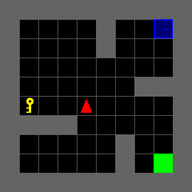

In [17]:
from IPython.display import Image as IPImage

TASKS = ('key', 'door', 'goal')

def record_gif(task, method="vlm", seed=0):
    ok, n, fr = run_episode_v2(env, model, objectives[method][task], task, seed,
                               HORIZON, MAX_STEPS, DEVICE, n_candidates=N_CAND,
                               replan_every=REPLAN_EVERY, record=True)
    
    path = f"/kaggle/working/plan_{task}_{method}_seed{seed}.gif"
    ims = [Image.fromarray(f).resize((192, 192), Image.LANCZOS) for f in fr]
    ims[0].save(path, save_all=True, append_images=ims[1:],
                duration=200, loop=0)
    print(f"{method}/{task} seed={seed}: "
          f"{'успех' if ok else 'не решил'} за {n} шагов -> {path}")
    return path

for t in TASKS:
    p = record_gif(t, "vlm", seed=1)
IPImage(filename=p)

In [15]:
from state_table import pin_terminal
goal_cell = tuple(int(c) for c in env.goal_pos)
tables["goal"] = pin_terminal(tables["goal"], states, [goal_cell])

### 8. Диагностика (по желанию)
**8a.** Уважает ли воображение стены: верхний ряд — сон декодера, нижний — реальная среда из той же позы. Если во сне агент проходит сквозь стену — вот источник «ходит в стену».
**8b.** Разброс objective по кандидатам + медиана NN-дистанции (≈0 — декоды попадают в эталоны таблицы).

In [ ]:
probe_imagination(model, env, DEVICE, seed=5, n_steps=6, action=1,
                  path="/kaggle/working/imagine_probe.png")
IPImage(filename="/kaggle/working/imagine_probe.png")